In [2]:
import os
import shutil
import numpy as np
from tqdm import tqdm
from datetime import datetime
import time

import timm
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torchinfo import summary

## Load data

In [3]:
from utils.data import PlantData

data_dir = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/squared'

train_percent = 0.6
val_percent = 0.2
test_percent = 0.2

batch_size = 2

random_seed = 8

torch.manual_seed(random_seed)
np.random.seed(random_seed)


data = PlantData(data_dir, batch_size, train_percent, test_percent, val_percent, random_seed)
# data.calc_split_sizes()    

train_dataloader, val_dataloader, test_dataloader = data.get_dataloaders()
data.get_split_info(classwise=False)                    

 Total dataset size 	: 221
 Train dataset size 	: 132
 Val dataset size 	: 44
 Test dataset size 	: 45



## Load checkpoint

In [4]:
checkpoint_file_path = "/home/takayuki/Desktop/summer2025/plants/training/checkpoints/checkpoint_06-23_19-32--32_tiny_lr_decay_convnextv2_tiny.fcmae_ft_in22k_in1k_epoch_100.pth"

if os.path.exists(checkpoint_file_path):
    print(f"Loading checkpoint from {checkpoint_file_path}")
    checkpoint = torch.load(checkpoint_file_path, map_location='cpu')
    
    print("Checkpoint Contents:")
    for key, value in checkpoint.items():
        content = key.ljust(30)
        print(f"{content}: {value if isinstance(value, (str, int, float)) else type(value)}")
    
    if 'hparams' in checkpoint:
        hparams = checkpoint['hparams']
        print("\nHyperparameters:")
        for key, value in hparams.items():
            content = key.ljust(30)
            print(f"{content}: {value}")
    
else:
    print(f"Could not find checkpoint at {checkpoint_file_path}")

Loading checkpoint from /home/takayuki/Desktop/summer2025/plants/training/checkpoints/checkpoint_06-23_19-32--32_tiny_lr_decay_convnextv2_tiny.fcmae_ft_in22k_in1k_epoch_100.pth
Checkpoint Contents:
epoch                         : 100
model_state_dict              : <class 'collections.OrderedDict'>
optimizer_state_dict          : <class 'dict'>
scheduler_state_dict          : <class 'dict'>
train_loss                    : 0.01762979175972842
log_dir                       : /home/takayuki/Desktop/summer2025/plants/training/runs/convnextv2/06-23_19-32--32_tiny_lr_decay_convnextv2_tiny.fcmae_ft_in22k_in1k
best_val_accuracy             : 0.9090909090909091
best_val_epoch                : 44
hparams                       : <class 'dict'>

Hyperparameters:
a_run_name                    : tiny_lr_decay
initial_learning_rate         : 0.0005
final_learning_rate           : 1e-06
num_epochs                    : 100
batch_size                    : 2
data_directory                : /home/takayuki

#### Model

In [5]:
model_name = checkpoint['hparams']['model_architecture']
optimizer_name = checkpoint['hparams']['optimizer']
scheduler_name = checkpoint['hparams']['scheduler']
criterion_name = checkpoint['hparams']['criterion']

model = timm.create_model(model_name, pretrained=False, num_classes=data.num_classes)
model.load_state_dict(checkpoint['model_state_dict'])

for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

trainable_params = [p for p in model.parameters() if p.requires_grad]
print("Number of trainable parameters: ", sum(p.numel() for p in trainable_params))

Number of trainable parameters:  16149


In [6]:
best_val_accuracy = checkpoint.get('best_val_accuracy', 0.0)
best_val_epoch = checkpoint.get('best_val_epoch', 0)

initial_learning_rate = checkpoint['hparams'].get('initial_learning_rate', 0.00001)
final_learning_rate = checkpoint['hparams'].get('final_learning_rate', 0.000001)

if optimizer_name == 'AdamW':
    optimizer = torch.optim.AdamW(trainable_params, lr=initial_learning_rate)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
else:
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")

if scheduler_name == 'CosineAnnealingLR':
    scheduler = CosineAnnealingLR(optimizer, T_max=checkpoint['hparams']['num_epochs'], eta_min=final_learning_rate)
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])   
else:
    raise ValueError(f"Unsupported scheduler: {scheduler_name}")

if criterion_name == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported criterion: {criterion_name}")

num_epochs = checkpoint['hparams']['num_epochs']

# print(model)

## Training Loop
- Tensorboard logging
- Save model checkpoints
- Save best models

In [7]:
# Paths
checkpoint_path = "/home/takayuki/Desktop/summer2025/plants/training/checkpoints"
models_path = "/home/takayuki/Desktop/summer2025/plants/training/models"
base_logs_path = "/home/takayuki/Desktop/summer2025/plants/training/runs/resumed/connextv2"

os.makedirs(checkpoint_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)
os.makedirs(base_logs_path, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
print(f"Using device: {device}, {torch.cuda.get_device_name(device) if device.type == 'cuda' else 'CPU'}")

Using device: cpu, CPU


In [10]:
# New Parameters 
run_name = "resuming_from_checkpoint_check"
new_initial_learning_rate = 0.00005
new_final_learning_rate = 0.000001
total_num_epochs = 150

checkpoint_interval = 20
validation_interval = 1

# comment these out if you want to resume from the checkpoint state wihith the old parameters - else overwrite them
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(trainable_params, lr=new_initial_learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=total_num_epochs, eta_min=new_final_learning_rate)


#### Make a copy of the logs

In [11]:
now = datetime.now()
timestamp = now.strftime("%m-%d_%H-%M--%S")

previous_logs_dir = checkpoint['log_dir']
new_logs_dir = os.path.join(base_logs_path, f"{run_name}.{timestamp}")

# copy all files from previous logs directory to new logs directory
if os.path.exists(previous_logs_dir):
    os.makedirs(new_logs_dir, exist_ok=True)
    for filename in os.listdir(previous_logs_dir):
        src_file = os.path.join(previous_logs_dir, filename)
        dst_file = os.path.join(new_logs_dir, filename)
        if os.path.isfile(src_file):
            with open(src_file, 'rb') as fsrc, open(dst_file, 'wb') as fdst:
                fdst.write(fsrc.read())

writer = SummaryWriter(log_dir=new_logs_dir)

In [13]:
now = datetime.now()
timestamp = now.strftime("%m-%d_%H-%M--%S")

previous_logs_dir = checkpoint['log_dir']
new_logs_dir = os.path.join(base_logs_path, f"{run_name}.{timestamp}")

# copy all files from previous logs directory to new logs directory
if os.path.exists(previous_logs_dir):
    os.makedirs(new_logs_dir, exist_ok=True)
    for filename in os.listdir(previous_logs_dir):
        src_file = os.path.join(previous_logs_dir, filename)
        dst_file = os.path.join(new_logs_dir, filename)
        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)

writer = SummaryWriter(log_dir=new_logs_dir)

hparams_dict = checkpoint['hparams']
hparams_dict.update({
    'run_name': run_name,
    'resumed_from_run_name': checkpoint['hparams']['a_run_name'],
    'previous_num_epochs': checkpoint['hparams']['num_epochs'],
    'checkpoint_from_epoch': checkpoint['epoch'],
    'total_resumed_epochs': total_num_epochs,
    'new_initial_learning_rate': new_initial_learning_rate,
    'new_final_learning_rate': new_final_learning_rate,
    'new_sc'
    'timestamp': timestamp,
})

for key, value in hparams_dict.items():
    writer.add_text(key, str(value))

## ~~~ Training loop ~~~ ##

print("Starting training...")
start_time = time.time()
for epoch in range(checkpoint['epoch'], total_num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / total
    train_accuracy = correct / total
    
    print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy*100:.4f}%")
    
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Accuracy/train', train_accuracy, epoch)
    
    # Validation phase
    if (epoch + 1) % validation_interval == 0:
        model.eval()  
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():  
            
            for val_images, val_labels in val_dataloader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                
                val_outputs = model(val_images)
                val_loss = criterion(val_outputs, val_labels)
                
                val_running_loss += val_loss.item() * val_images.size(0)
                _, val_predicted = torch.max(val_outputs.data, 1)
                val_total += val_labels.size(0)
                val_correct += (val_predicted == val_labels).sum().item()
        
        val_loss = val_running_loss / val_total
        val_accuracy = val_correct / val_total

        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy*100:.4f}%")
        
        writer.add_scalar('Loss/validation', val_loss, epoch)
        writer.add_scalar('Accuracy/validation', val_accuracy, epoch)
        
        # best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_val_epoch = epoch + 1
            
            # Delete previous best model if exists
            best_model_name = f"best_model_{timestamp}_{run_name}_{model_name}.pth"
            best_model_file_path = os.path.join(models_path, best_model_name)
            
            if os.path.exists(best_model_file_path):
                os.remove(best_model_file_path)
            
            # Save the new one
            torch.save(model.state_dict(), best_model_file_path)
            print(f"Saved new best model: {best_model_file_path}")
            print(f"Best Validation Accuracy: {best_val_accuracy*100:.4f}% at Epoch {best_val_epoch}")
            writer.add_scalar('Best_Validation_Accuracy', best_val_accuracy, epoch)
    
    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Learning_Rate', current_lr, epoch)
    
    # Checkpoint saving phase
    if (epoch + 1) % checkpoint_interval == 0 or epoch == num_epochs - 1:
        checkpoint_name = f"checkpoint_{timestamp}_{run_name}_{model_name}_epoch_{epoch + 1}.pth"
        checkpoint_file_path = os.path.join(checkpoint_path, checkpoint_name)
        
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss, 
            'log_dir': writer.log_dir,
            'best_val_accuracy': best_val_accuracy,
            'best_val_epoch': best_val_epoch,
            'hparams': hparams_dict
        }, checkpoint_file_path)
        
        print(f"Saved checkpoint: {checkpoint_file_path}")

print("\nTraining complete.")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Best Validation Accuracy: {best_val_accuracy*100:.4f}% at Epoch {best_val_epoch}")
print(f"Final Training Accuracy: {train_accuracy*100:.4f}%")
print("\nRun ID: ")
print(f"{timestamp}_{run_name}_{model_name}")
  

Starting training...


Epoch 101/100: 100%|██████████| 66/66 [00:28<00:00,  2.28batch/s]


Training Loss: 0.0186, Training Accuracy: 100.0000%
Validation Loss: 0.4490, Validation Accuracy: 90.9091%


Epoch 102/100: 100%|██████████| 66/66 [00:28<00:00,  2.34batch/s]


Training Loss: 0.0243, Training Accuracy: 100.0000%
Validation Loss: 0.4473, Validation Accuracy: 90.9091%


...

Training Loss: 0.0143, Training Accuracy: 100.0000%
Validation Loss: 0.4298, Validation Accuracy: 90.9091%


Epoch 149/100: 100%|██████████| 66/66 [00:53<00:00,  1.24batch/s]


Training Loss: 0.0175, Training Accuracy: 100.0000%
Validation Loss: 0.4266, Validation Accuracy: 90.9091%


Epoch 150/100: 100%|██████████| 66/66 [00:43<00:00,  1.52batch/s]


Training Loss: 0.0200, Training Accuracy: 100.0000%
Validation Loss: 0.4256, Validation Accuracy: 90.9091%

Training complete.
Best Validation Accuracy: 90.9091% at Epoch 44
Final Training Accuracy: 100.0000%

Run ID: 
06-24_15-34--38_resuming_from_checkpoint_check_convnextv2_tiny.fcmae_ft_in22k_in1k


In [14]:
print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_accuracy*100:.4f}% at Epoch {best_val_epoch}")
print(f"Final Training Accuracy: {train_accuracy*100:.4f}%")
print("\nRun ID: ")
print(f"{timestamp}_{run_name}_{model_name}")


Training complete.
Best Validation Accuracy: 90.9091% at Epoch 44
Final Training Accuracy: 100.0000%

Run ID: 
06-24_15-34--38_resuming_from_checkpoint_check_convnextv2_tiny.fcmae_ft_in22k_in1k


### Hyperparameters get logged to tensorboard only if the following block is executed after noting observations

## Evaluation script


Starting evaluation on the test set...


Evaluating: 100%|██████████| 23/23 [00:08<00:00,  2.69batch/s]



--- Test Set Evaluation Results ---
Overall Accuracy: 0.7778 (77.78%)

Classification Report:
                          precision    recall  f1-score   support

      Brasenia schreberi       0.67      1.00      0.80         2
                 Cabomba       1.00      1.00      1.00         1
  Ceratophyllum demersum       1.00      1.00      1.00         4
       Elodea canadensis       1.00      1.00      1.00         3
      Heteranthera dubia       0.00      0.00      0.00         1
Hydrocharis morsus-ranae       0.00      0.00      0.00         1
  Myriophyllum sibiricum       0.00      0.00      0.00         1
   Myriophyllum spicatum       0.75      1.00      0.86         3
          Najas flexilis       1.00      1.00      1.00         1
      Nitellopsis obtusa       0.50      1.00      0.67         1
        Nuphar variegata       0.00      0.00      0.00         1
        Nymphaea odorata       0.67      1.00      0.80         2
     Potamogeton crispus       1.00      0.50 

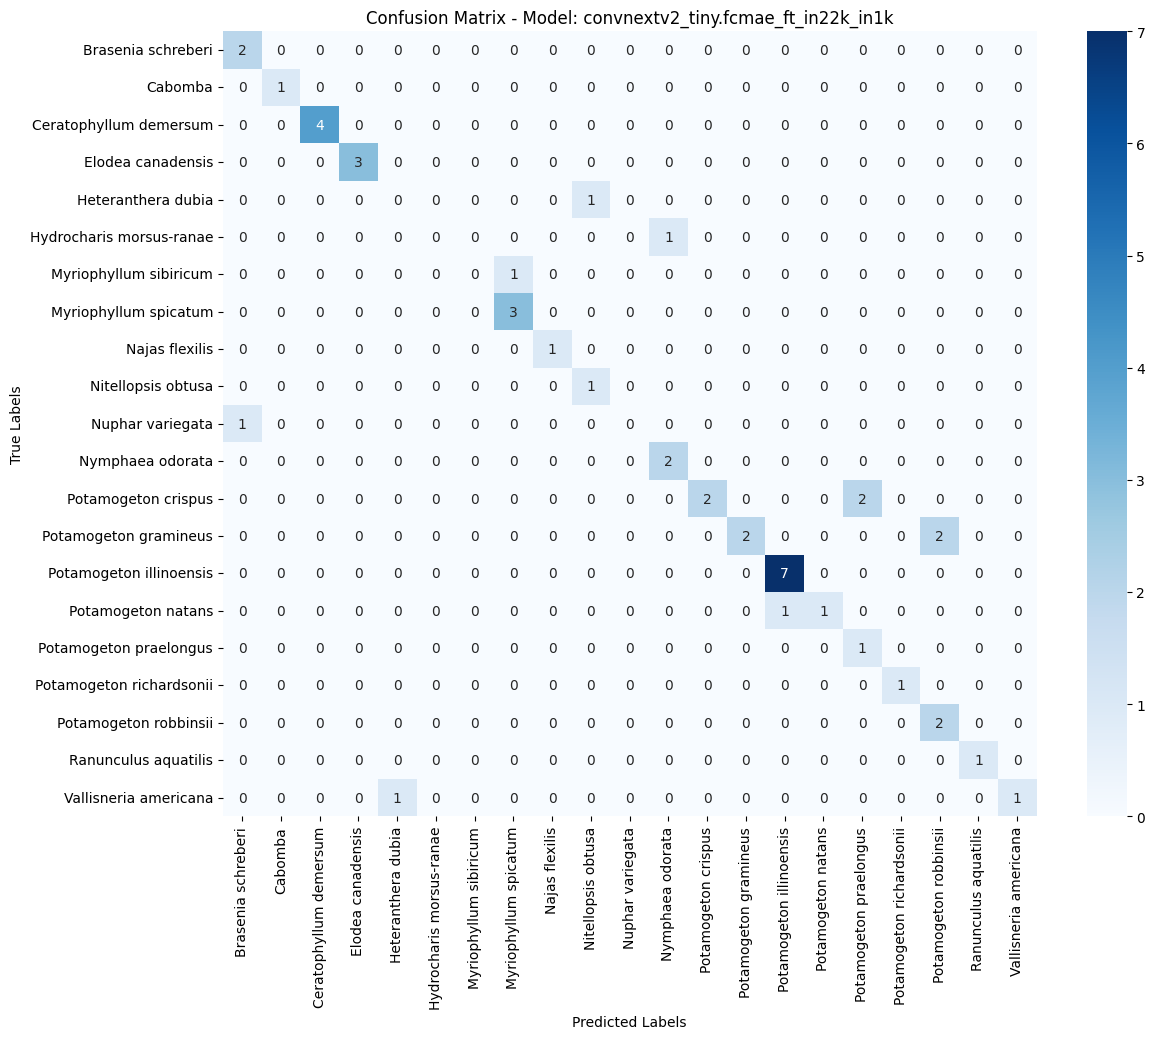

In [16]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_on_test_set(model_to_evaluate, dataloader, current_device, class_names_list):
    print("\nStarting evaluation on the test set...")
    model_to_evaluate.eval()  

    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", unit="batch"):
            images = images.to(current_device)
            labels = labels.to(current_device)

            outputs = model_to_evaluate(images)
            _, predicted_classes = torch.max(outputs, 1) 

            all_predictions.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())


    print("\n--- Test Set Evaluation Results ---")

    accuracy = accuracy_score(all_true_labels, all_predictions)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print("\nClassification Report:")
    report_labels_indices = list(range(len(class_names_list)))
    print(classification_report(all_true_labels, all_predictions,
                                labels=report_labels_indices,
                                target_names=class_names_list,
                                zero_division=0)) 

    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_true_labels, all_predictions, labels=report_labels_indices)
    print(cm)

    plt.figure(figsize=(max(8, len(class_names_list)*0.6), max(6, len(class_names_list)*0.5)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names_list,
                yticklabels=class_names_list)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - Model: {model_name}")
    plt.tight_layout() 
    
    return accuracy, all_true_labels, all_predictions

# model.load_state_dict(torch.load(best_model_file_path, map_location=device))
model.eval()  

test_accuracy, true_labels, predictions = evaluate_model_on_test_set(model, test_dataloader, device, data.dataset_init.classes)

#### Some evaluation metrics
- Accuracy: correct predictions / total predictions
- Precision: TP / (TP + FP)
- Recall: TP / (TP + FN)
- F1 Score: Harmonic mean of precision and recall

In [17]:
observations = f"training further on a low learning rate improved test accuracy from 73% to {test_accuracy*100:.2f}%.\n"
    
hparams_dict["new_observations"] = observations
writer.add_text('New_Observations', observations)

# Save the final model
final_model_name = f"final_model_{model_name}_{timestamp}.pth"
final_model_file_path = os.path.join(models_path, final_model_name)
torch.save(model.state_dict(), final_model_file_path)
print(f"Saved final model: {final_model_file_path}")

# Write Metrics and Hyperparameters to TensorBoard

metrics = {
    "epochs_trained": total_num_epochs + 1,
    "final_train_loss": train_loss,
    "final_train_accuracy": train_accuracy,
    "final_val_loss": val_loss,
    "final_val_accuracy": val_accuracy,
    "best_val_accuracy": best_val_accuracy,
    "best_val_epoch": best_val_epoch,
    "final_test_accuracy": test_accuracy,
    "time_elapsed": elapsed_time,
}

writer.add_hparams(hparams_dict, metrics)
writer.flush()
writer.close()  

Saved final model: /home/takayuki/Desktop/summer2025/plants/training/models/final_model_convnextv2_tiny.fcmae_ft_in22k_in1k_06-24_15-34--38.pth
